# Unit 2 — The Math of Attention: QKᵀ, the √d_k Fix, and the Weighted Read

**Thesis:** attention is two matrix products glued by a softmax:

$$\mathrm{Attn}(Q,K,V) = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)\,V$$

**What we measure on SmolLM2-135M (layer 0):**
- Q, K, V as projections of real token embeddings
- 9 query heads sharing 3 KV heads (GQA footprint)
- scores growing ~√d_k → softmax saturation → the ÷√d_k fix
- attention output as a **weighted read** of the value vectors

**Constrains:**
- Permutation blind attention or invariant (dot-product only self-attention)
- Lacks positional encodings or Causal masks

In [3]:
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained("HuggingFaceTB/SmolLM2-135M")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M")

print("Model loaded:", type(model).__name__)
print("Hidden size (d_model):", model.config.hidden_size)
print("Layers:", model.config.num_hidden_layers)
print("Query heads:", model.config.num_attention_heads)
print("KV heads:", model.config.num_key_value_heads)

# head dimension 
print("d_k = embedding_size / query heads = ", model.config.hidden_size // model.config.num_attention_heads)
print("sqrt(d_k) =", np.sqrt(model.config.hidden_size // model.config.num_attention_heads))

c:\Users\Admin\OneDrive\Documents\Research_projects\pico_projects\linear-transformations-attention\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 272/272 [00:00<00:00, 738.49it/s]


Model loaded: LlamaModel
Hidden size (d_model): 576
Layers: 30
Query heads: 9
KV heads: 3
d_k = embedding_size / query heads =  64
sqrt(d_k) = 8.0


###  d_k = d_model / n_heads

d_k is the size of the slice each head gets. The 576-dimensional embedding is split into 9 equal parts of 64. Each head "owns" one and uses it to look for a different pattern.

###  query/key/value slice (d_k = 64) 


In [4]:
# checking the models specs
print(type(model))
print(model)

<class 'transformers.models.llama.modeling_llama.LlamaModel'>
LlamaModel(
  (embed_tokens): Embedding(49152, 576)
  (layers): ModuleList(
    (0-29): 30 x LlamaDecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear(in_features=576, out_features=576, bias=False)
        (k_proj): Linear(in_features=576, out_features=192, bias=False)
        (v_proj): Linear(in_features=576, out_features=192, bias=False)
        (o_proj): Linear(in_features=576, out_features=576, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
        (up_proj): Linear(in_features=576, out_features=1536, bias=False)
        (down_proj): Linear(in_features=1536, out_features=576, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
      (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)
    )
  )
  (norm): LlamaRMSNorm((576,), eps=1e-05)
  (rotary_emb): LlamaRotaryE

In [5]:
# grab weights from layer at first index[0] 

W_Q = model.layers[0].self_attn.q_proj.weight.detach().float().numpy()
W_K = model.layers[0].self_attn.k_proj.weight.detach().float().numpy()
W_V = model.layers[0].self_attn.v_proj.weight.detach().float().numpy()
W_O = model.layers[0].self_attn.o_proj.weight.detach().float().numpy()

for name, W in [("W_Q", W_Q), ("W_K", W_K), ("W_V", W_V), ("W_O", W_O)]:
    print(f"{name}: {W.shape}")

W_Q: (576, 576)
W_K: (192, 576)
W_V: (192, 576)
W_O: (576, 576)


## projection weights
### These are simulatneous dot-products done in transformed space

W_Q shape 576×576  →  9 query heads × 64 = 576      (full width)

W_K shape 192×576  →  3 KV heads × 64  = 192       (one third)

W_V shape 192×576  →  3 KV heads × 64  = 192       (one third)



In [6]:
sentence = "the cat sat on the mat"
ids = tokenizer.encode(sentence)
tokens = tokenizer.convert_ids_to_tokens(ids)

print("token IDs (logits):", ids)
print("tokens:   ", tokens)
print("num tokens n =", len(ids))

# Embeddings: X ∈ R^(n × d_model)
X = model.get_input_embeddings().weight[ids].float().detach().numpy()

# project to Q, K, V using transpose conversion

Q = X @ W_Q.T # (n, 576) @ (576, 576) -> (n, 576)
K = X @ W_K.T # (n, 576) @ (576, 192) -> (n, 192)
V = X @ W_V.T  # (n, 576) @ (576, 192) -> (n, 192)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

token IDs (logits): [1195, 2644, 2643, 335, 260, 1171]
tokens:    ['the', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat']
num tokens n = 6
Q shape: (6, 576)
K shape: (6, 192)
V shape: (6, 192)


### Calc Logic : Q = X @ W_Q.T      # your "B · A^T" with B = input, A = weight

## Grouped Query Attention(GQA)
### The 9 query heads are asymetrically used as 3 KV (key value) heads to save memory

#### Query heads:  
K1: [H0 H1 H2]

K2: [H3 H4 H5] 

K3: [H6 H7 H8]

#### Conceptual Layers:


GQA : KV heads: 3 shared, each serves 3 queries 

MQA : If we recognize each of 3 heads as a unit its example of MQA 

MHA : If we decouple the KV groups we get 9 heads

In [7]:
# reshaping Q / K / V into per-head slices
n, d_k = X.shape[0], 64
n_qh, n_kvh = 9, 3

Q9 = Q.reshape(n, n_qh, d_k)      # (6, 9, 64)
K3 = K.reshape(n, n_kvh, d_k)     # (6, 3, 64)
V3 = V.reshape(n, n_kvh, d_k)     # (6, 3, 64)

# splitting K/V
group_of = {h: h // (n_qh // n_kvh) for h in range(n_qh)}
print(group_of)

{0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2}


In [8]:
# getting 3 distinct attention heads
g = 0
Q_g = Q9[:, 0:3, :]     # (6, 3, 64)  three query heads
K_g = K3[:, 0, :]       # (6, 64)     shared KV head 0

S_g = np.einsum('ihd,jd->hij', Q_g, K_g)   # (3, 6, 6)
S_g_flat = S_g.reshape(-1)
print(S_g.shape, "| mean", S_g_flat.mean().round(3), "| std", S_g_flat.std().round(3))

#ponder: 
# Std is each tokens scoring against other tokens
# mean of tokens is 0.568

(3, 6, 6) | mean 0.568 | std 7.066


In [9]:
# saturation proof | We use exponent to scale to

def softmax(x):
    e = np.exp(x - x.max(-1, keepdims=True))
    return e / e.sum(-1, keepdims=True)
A_raw = softmax(S_g); A_scaled = softmax(S_g / 8.0)
H = lambda p: -(np.clip(p,1e-12,1) * np.log(np.clip(p,1e-12,1))).sum(-1)  # using exponential stability offset
print("entropy raw %.3f | scaled %.3f" % (H(A_raw).mean(), H(A_scaled).mean()))
print("maxprob raw %.3f | scaled %.3f" % (A_raw.max(-1).mean(), A_scaled.max(-1).mean()))

entropy raw 0.246 | scaled 1.522
maxprob raw 0.916 | scaled 0.391


## Attention output = weighted read of shared values

For one head $h$ and one query token $i$:

$$\mathrm{out}_h[i] = \sum_j A_h[i,j]\, V[j]$$

- $A_h[i,j]$ = attention weight (the scaled softmax) that query $i$ puts on key $j$
- $V[j]$ = value vector of token $j$
- because $\sum_j A_h[i,j] = 1$, this is a **convex combination** — a weighted average: token $i$ *reads* the context, leaning most on the tokens its query liked

**einsum:** `'hij,jd->hid'` — contract `j` (the sum over keys), keep head `h`, token `i`, dim `d`. The whole attention read is one line.

**All 9 heads at once (this is GQA made visible):**
Q has 9 heads but K/V have 3, so we reshape Q to `(token, group, qhead-in-group, dim)` = `(6, 3, 3, 64)`.

`np.einsum('igpd,jgd->gpij', Q9g, K3)` — the shared-group label `g` appears on both sides and in the output, so it **aligns** each query head with its one shared KV head (no summing over it). Result: all 9 heads' score matrices in one call → softmax → weighted read:

`np.einsum('gpij,jgd->gpid', A_all, V3)` → (group, qhead, token, dim) → reshape → (n, 576).

**Head fusion:** `resid = out_all @ W_O.T`. The 576×576 `W_O` mixes the 9 heads' independent findings before the MLP sees the result.

In [10]:
# attention = weighted read of shared values

def softmax(x):
    e = np.exp(x - x.max(-1, keepdims=True))
    return e / e.sum(-1, keepdims=True)

# group 0: weighted read + hand-checked entry
S_g   = np.einsum('ihd,jd->hij', Q9[:, 0:3], K3[:, 0])   # (3,6,6) scores
A_g   = softmax(S_g / 8.0)                                # ÷√d_k already applied
out_g = np.einsum('hij,jd->hid', A_g, V3[:, 0])           # (3,6,64) weighted read

row = sum(A_g[0, 2, j] * V3[j, 0] for j in range(6))      # out[head0, token2] by hand
print("hand-check ok:", np.allclose(out_g[0, 2], row))    # True

# all 3 groups in ONE einsum -> 9 heads -> W_O mixing
A_all   = softmax(np.einsum('igpd,jgd->gpij', Q9.reshape(6, 3, 3, 64), K3) / 8.0)
out_all = np.einsum('gpij,jgd->gpid', A_all, V3)           # (3,3,6,64)
out_all = out_all.transpose(2, 0, 1, 3).reshape(6, 576)    # heads 0-8 in order
resid   = out_all @ W_O.T                                  # (6,576)

print("out_all:", out_all.shape, "| resid:", resid.shape)
print("rows of A sum to 1:", np.allclose(A_g.sum(-1), 1))

hand-check ok: True
out_all: (6, 576) | resid: (6, 576)
rows of A sum to 1: True


## What the ÷√d_k fix looks like

Numbers we measured:
- raw scores: std ≈ 7.07 (theory predicted √64 = 8) → max scores ~3σ ≈ 21
- `softmax(S)`   → entropy 0.25, max prob 0.92 → **one-hot**, attention copies a single token
- `softmax(S/8)` → entropy 1.52, max prob 0.39 → **soft spread**, attention reads context

The entropy max for 6 tokens is log 6 ≈ 1.79 (uniform). Three graphs make it visible.

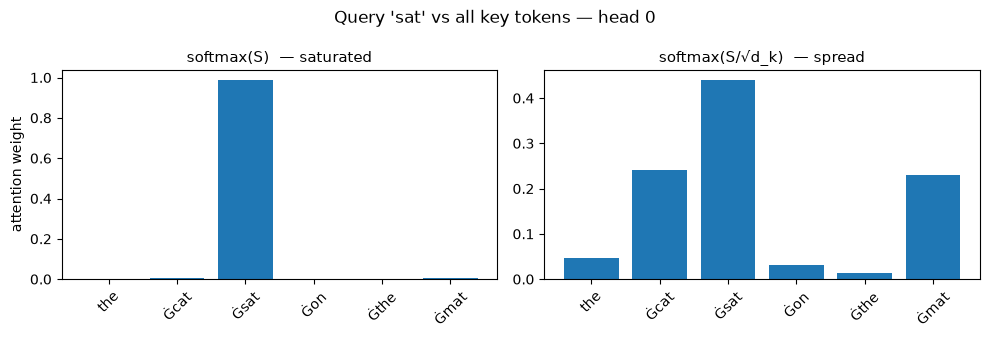

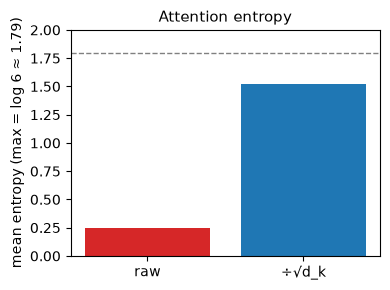

C:\Users\Admin\AppData\Local\Temp\ipykernel_17696\3885915676.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


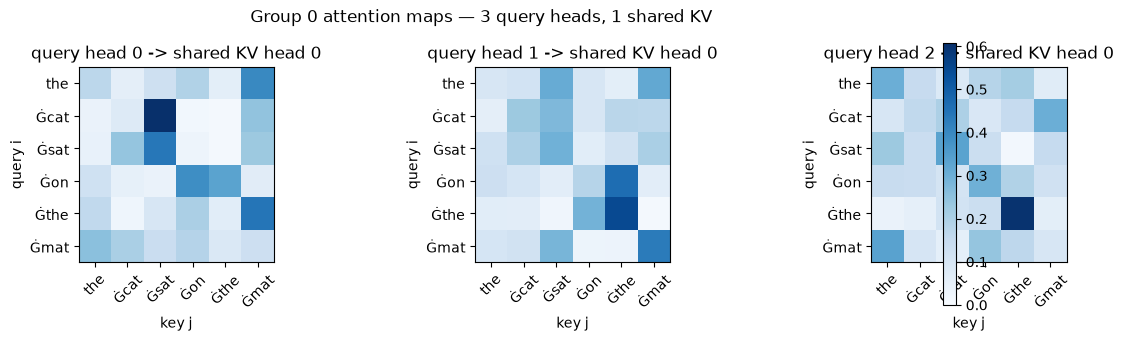

: 

In [ ]:
import matplotlib.pyplot as plt

# 1) raw vs scaled softmax for query token "sat" (index 2), head 0
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, A, title in zip(axes, [A_raw, A_scaled],
                        ["softmax(S)  — saturated", "softmax(S/√d_k)  — spread"]):
    ax.bar(range(6), A[0, 2], color="#1f77b4")
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(6), tokens, rotation=45)
axes[0].set_ylabel("attention weight")
plt.suptitle("Query 'sat' vs all key tokens — head 0", fontsize=12)
plt.tight_layout(); plt.show()

# 2) entropy: raw vs scaled (uniform over 6 tokens = log 6 ≈ 1.79)
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["raw", "÷√d_k"], [H(A_raw).mean(), H(A_scaled).mean()],
       color=["#d62728", "#1f77b4"])
ax.axhline(np.log(6), color="gray", ls="--", lw=1)
ax.set_ylim(0, 2)
ax.set_ylabel("mean entropy (max = log 6 ≈ 1.79)")
ax.set_title("Attention entropy", fontsize=11)
plt.tight_layout(); plt.show()

# 3) heatmaps: 3 query heads of group 0, one shared KV head
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for h in range(3):
    im = axes[h].imshow(A_scaled[h], cmap="Blues", vmin=0, vmax=A_scaled.max())
    axes[h].set_title(f"query head {h} -> shared KV head 0")
    axes[h].set_xticks(range(6), tokens, rotation=45)
    axes[h].set_yticks(range(6), tokens)
    axes[h].set_xlabel("key j"); axes[h].set_ylabel("query i")
fig.colorbar(im, ax=axes, fraction=0.02)
plt.suptitle("Group 0 attention maps — 3 query heads, 1 shared KV", fontsize=12)
plt.tight_layout(); plt.show()

## Unit 2 — Conclusion

| Claim (hypothesis) | Measured | Verdict |
|---|---|---|
| dot products of 64-dim vectors grow ~√d_k = 8 | score std = 7.07 | ✓ |
| raw softmax saturates (near one-hot) | entropy 0.25, max prob 0.92 | ✓ |
| ÷√d_k restores soft spread | entropy 1.52, max prob 0.39 | ✓ |
| GQA: 9 query heads share 3 KV heads | K, V width = 192 = 576/3 | ✓ |
| attention = weighted read of values | hand-check + einsum match | ✓ |

**The formula, fully understood:**

$$\mathrm{Attn}(Q,K,V) = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)\,V$$

- `QKᵀ` — every token scores every token; scores grow ~√d_k
- `÷√d_k` — rescale so softmax stays soft and gradients flow
- `softmax` — scores become a probability distribution over keys
- `·V` — the weighted read: pull the value vectors those keys point to

**Issue → hypothesis → fix:** scores too big → softmax collapses to one-hot → divide by √d_k. Proven on SmolLM2's real layer-0 weights.

**Next — Unit 3 (RoPE):** the real model never multiplies raw q·k — it first *rotates* q and k by their token position (θ = 100000), so attention encodes *where* a token is, not just *what* it is. We'll prove `q_i·k_j` depends only on the gap `i − j`.